# Welcome to Colab!

## Autoencoders for Image Denoising

Autoencoders are neural networks designed to learn efficient data codings in an unsupervised manner. The goal is to learn a representation (encoding) for a set of data, typically for dimensionality reduction, by training the network to ignore 'noise' in the input. For denoising, an autoencoder is trained to reconstruct clean input images from corrupted, noisy versions.

Here, we will:
1. Load the MNIST dataset.
2. Add random noise to the images.
3. Train a basic autoencoder to denoise the images.
4. Train a slightly more complex autoencoder (representing a 'tuned' model).
5. Visualize the results to compare their performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"Original training data shape: {x_train.shape}")
print(f"Original test data shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training data shape: (60000, 784)
Original test data shape: (10000, 784)


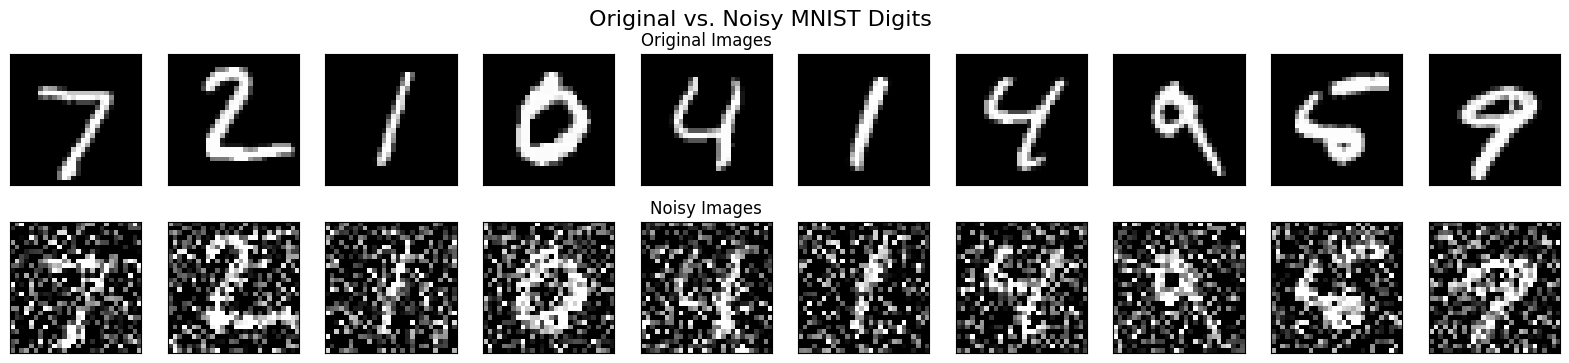

In [2]:
# Add noise to the images
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to ensure they remain within [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Display some noisy images vs original
n = 10 # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Original Images")

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Noisy Images")
plt.suptitle("Original vs. Noisy MNIST Digits", fontsize=16)
plt.show()

### Basic Autoencoder (Without 'Hyperparameter Tuning')

This model will use a simple architecture: an encoder with one hidden layer and a decoder with one hidden layer, aiming for a relatively small latent space dimension. We'll use default activation functions and a standard optimizer.

In [3]:
input_dim = 784 # 28*28
hidden_dim_basic = 128
latent_dim_basic = 64

# Encoder for basic model
input_img_basic = Input(shape=(input_dim,))
encoded_basic = Dense(hidden_dim_basic, activation='relu')(input_img_basic)
encoded_basic = Dense(latent_dim_basic, activation='relu')(encoded_basic)

# Decoder for basic model
decoded_basic = Dense(hidden_dim_basic, activation='relu')(encoded_basic)
decoded_basic = Dense(input_dim, activation='sigmoid')(decoded_basic) # Output layer uses sigmoid for pixel values between 0 and 1

# Autoencoder model
autoencoder_basic = Model(input_img_basic, decoded_basic)
autoencoder_basic.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

print("Basic Autoencoder Summary:")
autoencoder_basic.summary()

Basic Autoencoder Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

Training Basic Autoencoder...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.2505 - val_loss: 0.1853
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1684 - val_loss: 0.1549
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1490 - val_loss: 0.1416
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1397 - val_loss: 0.1366
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1341 - val_loss: 0.1308
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1302 - val_loss: 0.1278
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1274 - val_loss: 0.1255
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1252 - val_loss: 0.1236
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1235 - val_loss: 0.1225
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1219 - val_loss: 0.1207


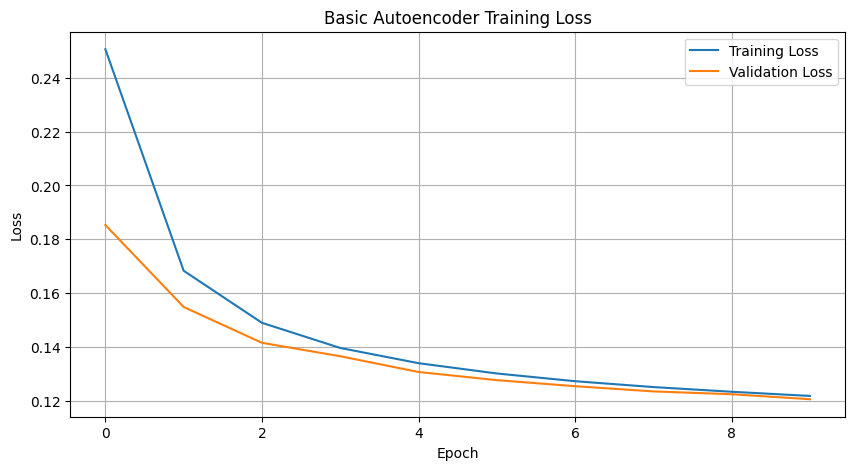

In [4]:
print("Training Basic Autoencoder...")
history_basic = autoencoder_basic.fit(x_train_noisy, x_train, # Input is noisy, target is clean
                                      epochs=10,
                                      batch_size=256,
                                      shuffle=True,
                                      validation_data=(x_test_noisy, x_test))

plt.figure(figsize=(10, 5))
plt.plot(history_basic.history['loss'], label='Training Loss')
plt.plot(history_basic.history['val_loss'], label='Validation Loss')
plt.title('Basic Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


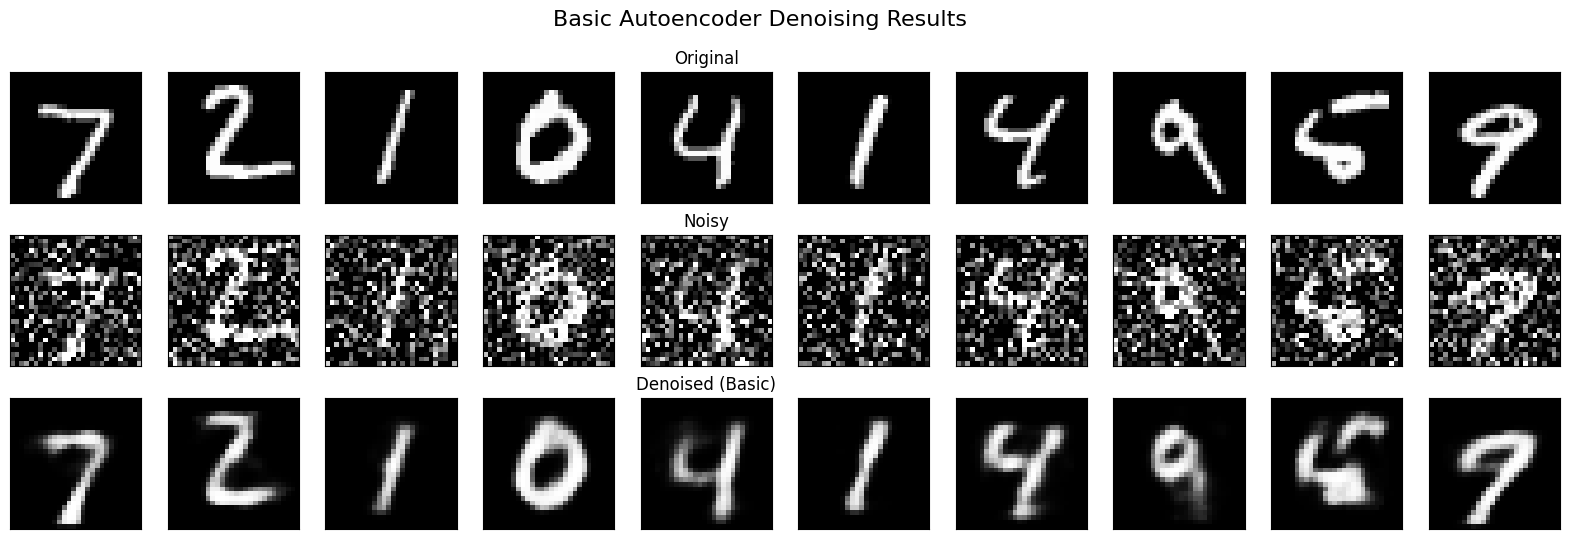

In [6]:
# Denoise images using the basic autoencoder
denoised_images_basic = autoencoder_basic.predict(x_test_noisy)

# Visualize results from the basic model
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Original")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Noisy")

    # Denoised (Basic Model)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images_basic[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Denoised (Basic)")
plt.suptitle("Basic Autoencoder Denoising Results", fontsize=16)
plt.show()

### 'Tuned' Autoencoder (Demonstrating Architectural Choices)

For a 'tuned' model, we might experiment with more layers, different latent dimensions, or activation functions, and potentially adjust the learning rate. Here, we'll create a slightly deeper autoencoder with a different latent space size and a different learning rate to simulate the effect of architectural hyperparameter tuning.

In [7]:
input_dim = 784 # 28*28
hidden1_tuned = 256
hidden2_tuned = 128
latent_dim_tuned = 32 # Smaller latent space to force more compression

# Encoder for tuned model
input_img_tuned = Input(shape=(input_dim,))
encoded_tuned = Dense(hidden1_tuned, activation='elu')(input_img_tuned) # Using ELU activation
encoded_tuned = Dense(hidden2_tuned, activation='elu')(encoded_tuned)
encoded_tuned = Dense(latent_dim_tuned, activation='elu')(encoded_tuned)

# Decoder for tuned model
decoded_tuned = Dense(hidden2_tuned, activation='elu')(encoded_tuned)
decoded_tuned = Dense(hidden1_tuned, activation='elu')(decoded_tuned)
decoded_tuned = Dense(input_dim, activation='sigmoid')(decoded_tuned)

# Autoencoder model
autoencoder_tuned = Model(input_img_tuned, decoded_tuned)
autoencoder_tuned.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error') # Using MSE loss and different LR

print("Tuned Autoencoder Summary:")
autoencoder_tuned.summary()

Tuned Autoencoder Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

Training Tuned Autoencoder...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0629 - val_loss: 0.0405
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0358 - val_loss: 0.0316
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0301 - val_loss: 0.0280
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 0.0273 - val_loss: 0.0256
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0254 - val_loss: 0.0243
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0240 - val_loss: 0.0231
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0230 - val_loss: 0.0222
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0223 - val_loss: 0.0216
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0217 - val_loss: 0.0212
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0211 - val_loss: 0.0206


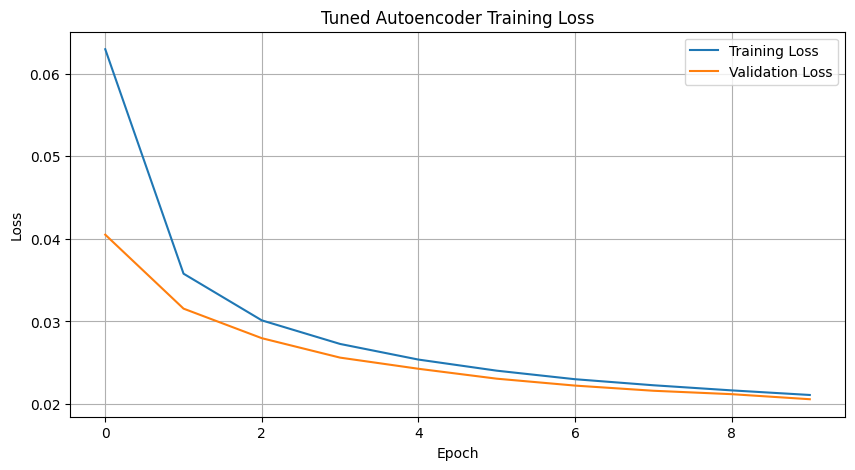

In [8]:
print("Training Tuned Autoencoder...")
history_tuned = autoencoder_tuned.fit(x_train_noisy, x_train,
                                      epochs=10,
                                      batch_size=256,
                                      shuffle=True,
                                      validation_data=(x_test_noisy, x_test))

plt.figure(figsize=(10, 5))
plt.plot(history_tuned.history['loss'], label='Training Loss')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss')
plt.title('Tuned Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


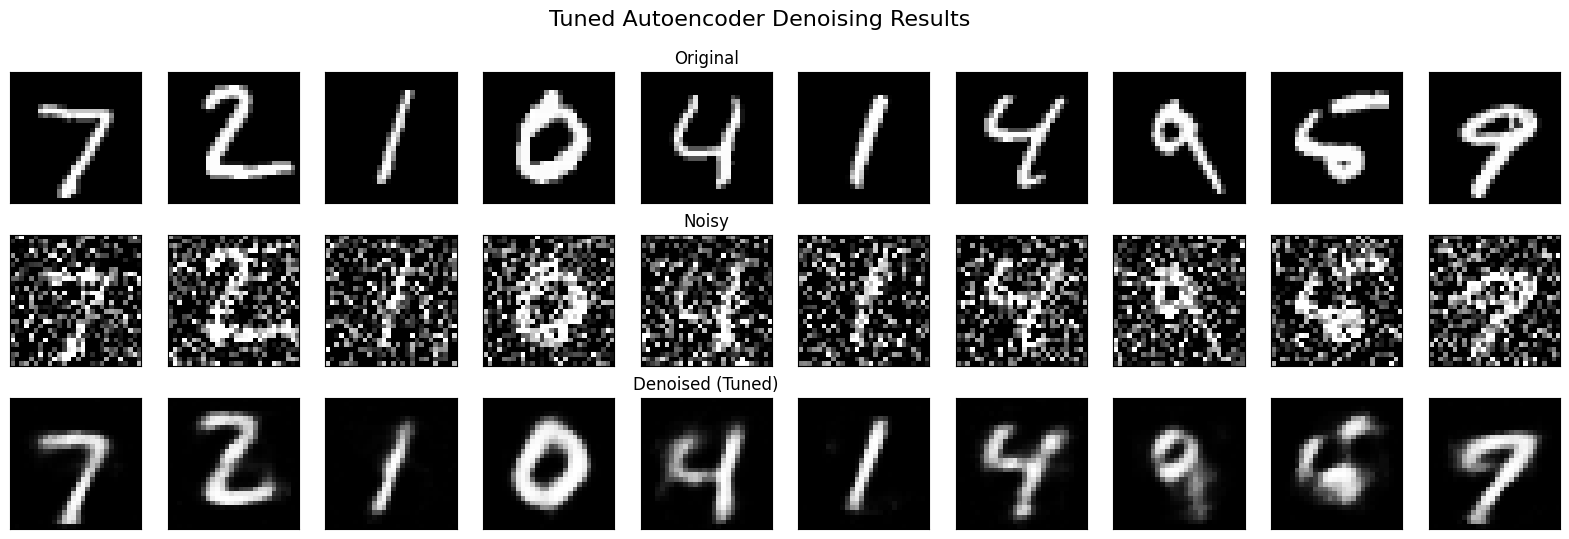

In [9]:
# Denoise images using the tuned autoencoder
denoised_images_tuned = autoencoder_tuned.predict(x_test_noisy)

# Visualize results from the tuned model
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Original")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Noisy")

    # Denoised (Tuned Model)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images_tuned[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2 -1: ax.set_title("Denoised (Tuned)")
plt.suptitle("Tuned Autoencoder Denoising Results", fontsize=16)
plt.show()